<img src="https://drive.google.com/uc?export=view&id=1KqxUpweTX5Q0jzMArpjgDDHOTpmGUdsk" width="300">

# Multi-Sensor Machine Learning for Flood Characterisation in South Yorkshire: Extent and Depth


---
### **GEOL0069 Final Project — Notebook 2 of 3**
## **Flood Extent Mapping from Sentinel-1 SAR: Semi-Supervised Labelling & Cross-Scene Model Comparison**
**Student ID: 25231865**

---

## Overview

Notebook 1 produced three scenes, all using the same Threshold Baseline change-detection definition (VV difference < -3 dB and VV mid-flood < -17 dB):

| Scene | Role | Why |
|---|---|---|
| **Fishlake, Nov 2019** | **Training** | The flood event this project is built around |
| **Bentley/Toll Bar, Nov 2019** | **Spatial test** | Same flood event, ~8 km away, different landscape |
| **Fishlake, Jan 2021** | **Temporal test** | Same location as training, different flood event (Storm Christoph) |

Two choices we make in this notebook to improve robustness:

**Avoiding circular labels.** The training scene is split into a confident core (pixels far from either Threshold Baseline threshold, labelled by Threshold Baseline's verdict) and an ambiguous margin (pixels close to either threshold, given no label at all). Models are trained only on the confident core; they then make predictions for the ambiguous margin.

**Testing generalisation.** Comparing a model's rollout on a scene against that same scene's own Threshold Baseline, when the model was trained on that scene, tells you how well it memorised the training data. The **spatial** and **temporal** test scenes are never seen during training, so comparing each model's rollout against their own independently-computed Threshold Baseline masks tests generalisation, across space and across time.

## What this notebook does

| Step | Description |
|---|---|
| 2.1 | Load the three scenes from Notebook 1 |
| 2.2 | Build the 9-feature stack for each scene |
| 2.3 | Compute Threshold Baseline for each scene; split the training scene into confident core / ambiguous margin |
| 2.4 | Extract 3x3 patches (for the CNN) and prepare the training set |
| 2.5-2.7 | Train **Random Forest**, **SVM**, and a small **CNN** on the confident core only |
| 2.8 | Held-out comparison on the confident-core task itself |
| 2.9 | Ambiguous-margin analysis (training scene) |
| 2.10 | Spatial generalisation test (Bentley/Toll Bar) |
| 2.11 | Temporal generalisation test (Fishlake, Jan 2021) |
| 2.12 | Overall model comparison: held-out performance vs spatial vs temporal generalisation, and CO2 cost per model |
| 2.13 | Save outputs for Notebook 3 |

---

*GEOL0069 Final Project | UCL AI for Earth Observation 2025/26*

[GEOL0069 @ UCL 2025/26](https://github.com/CPOMUCL/GEOL0069-AI4EO)

---

In [35]:
# Mount Google Drive - allows access to saved data from Notebook 1
# + to save new outputs here
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [36]:
# Only CodeCaron needs installing here - scikit-learn, pandas, matplotlib + TensorFlow already installed
# CodeCarbon tracks CO2 of training the three models in sections 2.5-2.7
!pip install codecarbon -q
print("Packages ready.")

Packages ready.


In [37]:
import os
import numpy as np
import pandas as pd   # for tables of model comparison results
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches # for building custom legend entries
import matplotlib.colors as mcolors # for ListedColormap

from sklearn.ensemble import RandomForestClassifier # Section 2.5
from sklearn.svm import SVC # Section 2.6 (Support Vector Classifier)
from sklearn.preprocessing import StandardScaler # rescales features
from sklearn.pipeline import Pipeline # allows StandardScaler + SVC to work together
from sklearn.model_selection import train_test_split # splits confident-core pixels into train/held-out sets
from sklearn.metrics import (
    classification_report, f1_score, accuracy_score,
)

import tensorflow as tf
from tensorflow.keras import layers, models # needed for CNN (Section 2.7)

from codecarbon import EmissionsTracker # codecaron again, same as Notebook 1

# Same project directory as Notebook 1 - must point to same Drive folder
BASE_DIR = '/content/drive/MyDrive/AI4EO/Final_Project'
DIRS = {
    'processed': os.path.join(BASE_DIR, 'data', '01_processed'),
    'features':  os.path.join(BASE_DIR, 'data', '02_features'), # New output folder for this notebook
    'figures':   os.path.join(BASE_DIR, 'figures'),
    'results':   os.path.join(BASE_DIR, 'results'),
}
for p in DIRS.values():
    os.makedirs(p, exist_ok=True)

print("Imports and paths ready.") # Check cell has worked correctly
print(f"TensorFlow: {tf.__version__}")

Imports and paths ready.
TensorFlow: 2.20.0


## 2.1 Load Data from Notebook 1

We load all three scenes saved by Notebook 1. The temporal test scene (Fishlake, Jan 2021) reuses the training scene's DEM, since it's the same AOI.

In [38]:
data_path = os.path.join(DIRS['processed'], 'flood_data.npz')
if not os.path.exists(data_path):
    raise FileNotFoundError(
        "flood_data.npz not found, or doesn't contain the three-scene layout. "
        "Please run the updated Notebook 1 first."
    ) # Clearly informs us if Notebook 1 has not been run
    # avoid problems later

# allow_pickle=True needed because some saved items aren't plain numeric arrays
data = np.load(data_path, allow_pickle=True)
# scale was saved as single-element array, extract number and
# convert from NumPy integer type to Python integer
SCALE = int(data['scale'][0])

# Hard coded threshold values - same as notebook 1
# We recompute Threshold Baseline here in section 2.3
VV_DIFF_THRESHOLD = -3.0   # dB - Threshold Baseline thresholds, unchanged from Notebook 1
VV_ABS_THRESHOLD  = -17.0  # dB

# Dictionary of dictionaries - one entry per 'scene'
raw = {
    'train': dict(
        VV_pre=data['train_VV_pre'], VH_pre=data['train_VH_pre'],
        VV_mid=data['train_VV_mid'], VH_mid=data['train_VH_mid'],
        DEM=data['train_DEM'],
        label='Fishlake, Nov 2019 (training)',
    ),
    'spatial': dict(
        VV_pre=data['test_spatial_VV_pre'], VH_pre=data['test_spatial_VH_pre'],
        VV_mid=data['test_spatial_VV_mid'], VH_mid=data['test_spatial_VH_mid'],
        DEM=data['test_spatial_DEM'],
        label='Bentley/Toll Bar, Nov 2019 (spatial test)',
    ),
    'temporal': dict(
        VV_pre=data['test_temporal_VV_pre'], VH_pre=data['test_temporal_VH_pre'],
        VV_mid=data['test_temporal_VV_mid'], VH_mid=data['test_temporal_VH_mid'],
        DEM=data['train_DEM'],  # same AOI as training -> same DEM
        # this is because it is the same AOI as fishlake 2019, so can reuse DEM
        label='Fishlake, Jan 2021 (temporal test)',
    ),
}

# Brief summary of all three scenes - check each scene's array dimensions before processing
for key, d in raw.items():
    print(f"{key:9s} ({d['label']}): VV_pre {d['VV_pre'].shape}, DEM {d['DEM'].shape}")

train     (Fishlake, Nov 2019 (training)): VV_pre (287, 273), DEM (280, 446)
spatial   (Bentley/Toll Bar, Nov 2019 (spatial test)): VV_pre (286, 273), DEM (279, 446)
temporal  (Fishlake, Jan 2021 (temporal test)): VV_pre (294, 281), DEM (280, 446)


## 2.2 Build the Feature Stack for All Three Scenes

The same 9 features as before (`VV_pre`, `VH_pre`, `VV_mid`, `VH_mid`, `VV_diff`, `VH_diff`, `VV_VH_ratio_mid`, `elevation`, `slope`), computed identically for each scene with a single function so the three scenes are guaranteed to be processed consistently.

In [39]:
# Reminder of the 9 features relevant for this notebook:
# every model in this notebook is built on these 9 features, in this fixed
# order (the order is important:  it's how cube[:, :, i] is indexed later):
#   0 VV_pre   -- pre-flood VV backscatter (dB)
#   1 VH_pre   -- pre-flood VH backscatter (dB)
#   2 VV_mid   -- mid-flood VV backscatter (dB) - one of the two Threshold Baseline inputs
#   3 VH_mid   -- mid-flood VH backscatter (dB)
#   4 VV_diff  -- VV_mid - VV_pre -- the other Threshold Baseline input
#   5 VH_diff  -- VH_mid - VH_pre
#   6 VV_VH_ratio_mid -- VV_mid - VH_mid (a dB ratio): differences in how the
#                  two polarisations respond can help separate open water
#                  from flooded vegetation (double-bounce effects)
#   7 elevation -- DEM value (m)
#   8 slope     -- terrain steepness, derived from the DEM (see below)
FEATURE_NAMES = [
    'VV_pre', 'VH_pre', 'VV_mid', 'VH_mid',
    'VV_diff', 'VH_diff', 'VV_VH_ratio_mid',
    'elevation', 'slope',
]

def build_feature_stack(d, scale):
    """Align shapes and build the 9-feature cube (H, W, 9) for one scene."""
    VV_pre, VH_pre, VV_mid, VH_mid, DEM = d['VV_pre'], d['VH_pre'], d['VV_mid'], d['VH_mid'], d['DEM']
    # take the smallest height/width across all of them, and crop everything to that common size
    H = min(VV_pre.shape[0], VH_pre.shape[0], VV_mid.shape[0], VH_mid.shape[0], DEM.shape[0])
    W = min(VV_pre.shape[1], VH_pre.shape[1], VV_mid.shape[1], VH_mid.shape[1], DEM.shape[1])

    VV_pre_a, VH_pre_a   = VV_pre[:H, :W],  VH_pre[:H, :W]
    VV_mid_a, VH_mid_a = VV_mid[:H, :W], VH_mid[:H, :W]
    DEM_a = DEM[:H, :W]

    # Features 4-6
    VV_diff = VV_mid_a - VV_pre_a
    VH_diff = VH_mid_a - VH_pre_a
    ratio   = VV_mid_a - VH_mid_a  # dB subtraction = ratio in dB

    # np.gradient calculates the rate of change of elevation for each pixel in all directions
    # scale converts change per pixel to change per metre
    dz_dy, dz_dx = np.gradient(DEM_a, scale)
    # combining two directional gradients at each pixel
    # gives overall steepness (slope)
    slope = np.sqrt(dz_dx**2 + dz_dy**2)

    # np.stack combined the nine 2D (H, W) arrays into one 3D array of shape (H, W, 9)
    # order needs to match 'FEATURE_NAMES' above
    cube = np.stack(
        [VV_pre_a, VH_pre_a, VV_mid_a, VH_mid_a, VV_diff, VH_diff, ratio, DEM_a, slope],
        axis=-1,
    )
    return cube, H, W

# Build the feature cube for all three scenes
# + store everything needed in a dictionary per scene
scenes = {}
for key, d in raw.items():
    cube, H, W = build_feature_stack(d, SCALE)
    valid = ~np.any(np.isnan(cube), axis=-1) # pixel only valid if all 9 features are non-NaN
    scenes[key] = dict(label=d['label'], cube=cube, H=H, W=W, valid=valid)
    print(f"{key:9s}: cube {cube.shape}, valid pixels {valid.sum():,} / {valid.size:,} -- {d['label']}")

train    : cube (280, 273, 9), valid pixels 76,440 / 76,440 -- Fishlake, Nov 2019 (training)
spatial  : cube (279, 273, 9), valid pixels 76,167 / 76,167 -- Bentley/Toll Bar, Nov 2019 (spatial test)
temporal : cube (280, 273, 9), valid pixels 76,440 / 76,440 -- Fishlake, Jan 2021 (temporal test)


## 2.3 Threshold Baseline for Every Scene, and Confident-Core / Ambiguous-Margin Labelling

Threshold Baseline is computed identically for all three scenes. It's defined by absolute dB thresholds, not anything fitted to this AOI, so it applies unchanged.

For the **training scene only**, we then split valid pixels into:

- **Ambiguous margin**: pixels within `MARGIN_DIFF` dB of the -3 dB `VV_diff` threshold, *or* within `MARGIN_MID` dB of the -17 dB `VV_mid` threshold -- i.e. pixels close to either of Threshold Baseline's decision boundaries.
- **Confident core**: everything else, labelled by Threshold Baseline's verdict (1 = flooded, 0 = dry).

Only the confident core is used as training data. The margin gets no label and is analysed separately in Section 2.9.

If the confident-core class counts look too small/unbalanced, adjust `MARGIN_DIFF` / `MARGIN_MID`.

In [40]:
def compute_thresholdbaseline(cube):
    """Threshold Baseline mask from the aligned VV_diff (idx 4) and VV_mid (idx 2) channels."""
    # Pulls the relevant 2D feature maps out of cube by their known index (FEATURE_NAMES)
    VV_mid = cube[:, :, 2]
    VV_diff = cube[:, :, 4]
    return (VV_diff < VV_DIFF_THRESHOLD) & (VV_mid < VV_ABS_THRESHOLD)

# Calculate + report the Threshold Baseline for all three scenes
# used for spatial/temporal comparisons later (Sections 2.10/11)
for key, s in scenes.items():
    s['thresholdbaseline'] = compute_thresholdbaseline(s['cube'])
    n_flood = int(s['thresholdbaseline'][s['valid']].sum())
    n_valid = int(s['valid'].sum())
    print(f"{key:9s} Threshold Baseline: {n_flood:,} / {n_valid:,} valid px flooded "
          f"({100*n_flood/n_valid:.1f}%, {n_flood*(SCALE**2)/1e6:.2f} km^2) -- {s['label']}")

# -----------------------------------------------------------------------------
# CONFIDENT CORE vs AMBIGUOUS MARGIN (training scene only)
# -----------------------------------------------------------------------------

# Defines how close (in dB) a pixel can be to either threshold before it's considered ambiguous
MARGIN_DIFF = 2.0   # dB either side of the -3 dB VV-difference threshold
MARGIN_MID = 2.0   # dB either side of the -17 dB VV-mid threshold

train = scenes['train']
VV_mid_train = train['cube'][:, :, 2]
VV_diff_train = train['cube'][:, :, 4]

# for each of the two threshold conditions, flags pixels whose value is close to cutoff
near_diff_boundary = np.abs(VV_diff_train - VV_DIFF_THRESHOLD) < MARGIN_DIFF
near_mid_boundary = np.abs(VV_mid_train - VV_ABS_THRESHOLD) < MARGIN_MID

# pixel = ambiguous if its near either boundary (|)
ambiguous = (near_diff_boundary | near_mid_boundary) & train['valid']
# confident = anything else that's still valid
# aka comfortably away from both boundaries
confident = train['valid'] & ~ambiguous

# Store both masks on the training scene's dictionary to be used later
# used in section 2.4 and 2.9
train['ambiguous'] = ambiguous
train['confident'] = confident

# Provides counts for each category for us to inspect
# Enables us to check that the classes aren't wildly imbalanced
n_confident_flood = int((confident & train['thresholdbaseline']).sum())
n_confident_dry   = int((confident & ~train['thresholdbaseline']).sum())
n_ambiguous       = int(ambiguous.sum())

print(f"\nTraining scene labelling breakdown ({train['valid'].sum():,} valid px):")
print(f"  Confident flood (labelled 1): {n_confident_flood:,}")
print(f"  Confident dry   (labelled 0): {n_confident_dry:,}")
print(f"  Ambiguous margin (no label):  {n_ambiguous:,} "
      f"({100*n_ambiguous/train['valid'].sum():.1f}% of valid pixels)")

train     Threshold Baseline: 2,343 / 76,440 valid px flooded (3.1%, 0.94 km^2) -- Fishlake, Nov 2019 (training)
spatial   Threshold Baseline: 3,685 / 76,167 valid px flooded (4.8%, 1.47 km^2) -- Bentley/Toll Bar, Nov 2019 (spatial test)
temporal  Threshold Baseline: 375 / 76,440 valid px flooded (0.5%, 0.15 km^2) -- Fishlake, Jan 2021 (temporal test)

Training scene labelling breakdown (76,440 valid px):
  Confident flood (labelled 1): 1,166
  Confident dry   (labelled 0): 44,522
  Ambiguous margin (no label):  30,752 (40.2% of valid pixels)


## 2.4 Patches for the CNN, and Training Set Preparation

The CNN needs spatial context, so we extract a 3x3x9 patch around every pixel (following a patch-based approach seen in GEOL0069 Weeks 2-3). RF and SVM use the same 9 features but as a flat per-pixel vector.

**Scaling**: the per-channel mean/std used to scale features (for the CNN, and internally for the SVM pipeline) are computed from the training scene's confident-core pixels only, then applied to all three scenes. This avoids any information from the test scenes leaking into the scaling.

In [41]:
PATCH_SIZE = 3 # 3x3 area around each pixel, used for CNN

def extract_patches(cube, patch_size=3):
    H, W, C = cube.shape
    pad = patch_size // 2
    # 'edge' padding repeats the outermost row/column of pixels outward (duplicated edge values)
    # avoid crashes
    padded = np.pad(cube, ((pad, pad), (pad, pad), (0, 0)), mode='edge')
    # pre-allocate the output
    patches = np.empty((H, W, patch_size, patch_size, C), dtype=np.float32)

    # double loop runs patch_size*patch_size = 9 times
    # much faster than looping over every pixel individually
    for di in range(patch_size):
        for dj in range(patch_size):
            patches[:, :, di, dj, :] = padded[di:di + H, dj:dj + W, :]
    return patches

# -----------------------------------------------------------------------------
# SCALING: compute mean/std from the training scene's confident-core pixels
# only, then apply to all three scenes. Using only confident-core training
# pixels (not the ambiguous margin, and not the spatial/temporal test
# scenes) avoids any information about the test scenes leaking into how the
# data is scaled.
# -----------------------------------------------------------------------------

# Boolean-mask indexing: train['cube'][train['confident']] flattens the
# (H, W, 9) cube down to (N, 9), keeping only rows where 'confident' is True
# i.e. one row per confident-core pixel, each with its 9 feature values.
# Per-feature scaling stats from the training scene's confident core only
X_train_core_raw = train['cube'][train['confident']]
feature_mean = np.nanmean(X_train_core_raw, axis=0) # mean of each of the 9 features
feature_std  = np.nanstd(X_train_core_raw, axis=0) # std of each of the 9 features
feature_std[feature_std == 0] = 1.0 # protects against division by 0 if any feature has std=0

for key, s in scenes.items():
    # applies the same mean/std from training data to every scene's cube
    cube_scaled = (s['cube'] - feature_mean) / feature_std
    # any remaining NaN's become 0 after scaling
    cube_scaled = np.nan_to_num(cube_scaled, nan=0.0)
    s['cube_scaled'] = cube_scaled
    # patches are extracted from the scaled cube, so the CNN sees standardised inputs
    s['patches'] = extract_patches(cube_scaled, PATCH_SIZE)

# Reports the scaling statistics we actually used
# good to check whether elevation mean/std looks like Fishlake range from Notebook 1
print("Per-feature means (train confident core):")
for name, m, sd in zip(FEATURE_NAMES, feature_mean, feature_std):
    print(f"  {name:18s} mean={m:8.3f}  std={sd:8.3f}")
print(f"\nPatch shape per pixel: {scenes['train']['patches'].shape[2:]}") # should print (3, 3, 9)

# -----------------------------------------------------------------------------
# TRAINING SET: confident-core pixels of the training scene
# -----------------------------------------------------------------------------

CLASS_NAMES = ['Not flooded', 'Flooded'] # for labelling classification output later

mask_core = train['confident']
X_core = train['cube'][mask_core]        # raw 9-feature vectors (RF, and SVM internally scales)
P_core = train['patches'][mask_core]     # (n, 3, 3, 9) patches for the CNN
# .astype(np.int8) converts the boolean Threshold Baseline (T/F) into integers (1/0)
# Scikit-learn/keras expect this format (1/0) for class labels
y_core = train['thresholdbaseline'][mask_core].astype(np.int8)

print(f"\nConfident-core training set: {X_core.shape[0]:,} pixels "
      f"({100*y_core.mean():.1f}% flooded)") # mean of the 1/0 array out of 100%

# Splits the confident-core pixels into an 80% training set and a 20%
# held-out set, applying the same indices to X (RF/SVM
# features), P (CNN patches), and y (labels) simultaneously, so all the
# models are evaluated on exactly the same held-out pixels.
# stratify=y_core ensures both the train and test splits have the same
# proportion of flooded/not-flooded pixels as the full confident-core set --
# important given flooded pixels are a minority class.
X_train, X_test, P_train, P_test, y_train, y_test = train_test_split(
    X_core, P_core, y_core, test_size=0.2, random_state=42, stratify=y_core,
)
print(f"Held-out split -- train: {len(y_train):,}, test: {len(y_test):,}")

Per-feature means (train confident core):
  VV_pre             mean= -10.131  std=   3.397
  VH_pre             mean= -16.718  std=   2.922
  VV_mid             mean=  -9.925  std=   3.327
  VH_mid             mean= -17.311  std=   3.075
  VV_diff            mean=   0.205  std=   4.593
  VH_diff            mean=  -0.594  std=   4.081
  VV_VH_ratio_mid    mean=   7.386  std=   2.680
  elevation          mean=   5.108  std=   1.325
  slope              mean=   0.018  std=   0.027

Patch shape per pixel: (3, 3, 9)

Confident-core training set: 45,688 pixels (2.6% flooded)
Held-out split -- train: 36,550, test: 9,138


## 2.5 Random Forest

Trained on the confident-core pixels (Fishlake, Nov 2019) using the same hyperparameters as before.

In [42]:
# a single tracker instance is created here and reused (via .start()/.stop() calls) for SVM and CNN
# Each start/stop cycle appends one new row to emissions_log.csv
tracker = EmissionsTracker(
    project_name='Flood_Model_Comparison',
    output_dir=DIRS['results'],
    output_file='emissions_log.csv',
    log_level='warning', # suppress codecarbon's logs
)
tracker.start() # begins measuring energy use for whatever runs until .stop()

rf_model = RandomForestClassifier(
    n_estimators=200, # number of decision trees in the ensemble, more trees = more stable predictions
    min_samples_leaf=5, # each leaf must contain at least 5 training pixels - so trees do not memorise individual noisy pixels
    max_features='sqrt', # at each split, only consider a random sqrt(9)~3 of the 9 features
    class_weight='balanced', # re-weights the loss inversely to class frequency, so the minority (flooded) class is not ignored
    random_state=42, # fixes the RFs internal randomness for reproducability - can be changed
    n_jobs=-1, # use all available CPU cores to train trees in parallel
)
rf_model.fit(X_train, y_train) # actual training step

rf_emissions = tracker.stop() # CO2 tracker stops measuring, returns estimated kg CO2 for the .fit() call above

y_pred_rf = rf_model.predict(X_test) # predicted class (1/0) for each held-out pixel
rf_f1  = f1_score(y_test, y_pred_rf, average='weighted') # F1, weighted by how many pixels are in each class
rf_acc = accuracy_score(y_test, y_pred_rf) # fraction of held-out pixels predicted correctly

print("Random Forest -- held-out confident-core evaluation:")
# classification_report prints precision/recall/F1/support for each class, + overall averages
print(classification_report(y_test, y_pred_rf, target_names=CLASS_NAMES))
print(f"Weighted F1: {rf_f1:.4f}   Accuracy: {rf_acc:.4f}")
print(f"CO2 emissions (training): {rf_emissions*1000:.4f} g CO2e") # *1000 converts kg to g

[codecarbon WARNING @ 18:35:02] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon WARNING @ 18:35:02] We saw that you have a Intel(R) Xeon(R) CPU @ 2.20GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 18:35:02] We will use the default power consumption of 4 W per thread for your 2 CPU, so 8W.
[codecarbon WARNING @ 18:35:02] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon WARNING @ 18:35:02] No CPU tracking mode found. Falling back on CPU load mode.


Random Forest -- held-out confident-core evaluation:
              precision    recall  f1-score   support

 Not flooded       1.00      1.00      1.00      8905
     Flooded       1.00      1.00      1.00       233

    accuracy                           1.00      9138
   macro avg       1.00      1.00      1.00      9138
weighted avg       1.00      1.00      1.00      9138

Weighted F1: 1.0000   Accuracy: 1.0000
CO2 emissions (training): 0.0262 g CO2e


## 2.6 Support Vector Machine

An RBF-kernel SVM with internal standardisation, on the same confident-core training set.

In [43]:
tracker.start() # starting the same tracker from before, adding a new line to CSV

svm_model = Pipeline([
    # Unlike RF, SVMs with an RBF kernel are sensitive to feature scale
    # a feature ranging over thousands (e.g. raw elevation in metres) would
    # dominate one ranging over tens (e.g. dB values) unless rescaled.
    # StandardScaler rescales each feature to mean 0, std 1.
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', # non-linear kernel, so SVM can learn curved decision boundaries
                C=10.0, # regularisation strength: higher C = fit the training data more closely
                gamma='scale', # automatically scaled by the number of features and their variance
                class_weight='balanced', # re=weight for the minority flooded class
                random_state=42)),
]) # Wrapping scaler+model in a Pipeline means that .fit() fits the scaler on
# the training data and fits the SVM on the scaled result
# and any later .predict() call automatically applies that same fitted scaler first

MAX_SVM_TRAIN = 50_000 # SVM training costs can be high with greater number of training samples
# this limits the training set size
if len(X_train) > MAX_SVM_TRAIN:
    idx = np.random.default_rng(42).choice(len(X_train), MAX_SVM_TRAIN, replace=False) # reproducible random subsampling
    svm_model.fit(X_train[idx], y_train[idx])
    print(f"Subsampled training set to {MAX_SVM_TRAIN:,} pixels for SVM.")
else:
    svm_model.fit(X_train, y_train)

svm_emissions = tracker.stop() # stop tracking emissions for this SVM training

y_pred_svm = svm_model.predict(X_test)
svm_f1  = f1_score(y_test, y_pred_svm, average='weighted')
svm_acc = accuracy_score(y_test, y_pred_svm)

print("SVM -- held-out confident-core evaluation:")
print(classification_report(y_test, y_pred_svm, target_names=CLASS_NAMES))
print(f"Weighted F1: {svm_f1:.4f}   Accuracy: {svm_acc:.4f}")
print(f"CO2 emissions (training): {svm_emissions*1000:.4f} g CO2e")

[codecarbon WARNING @ 18:35:23] Already started tracking
[codecarbon WARNING @ 18:35:26] Tracker already stopped !


SVM -- held-out confident-core evaluation:
              precision    recall  f1-score   support

 Not flooded       1.00      1.00      1.00      8905
     Flooded       1.00      1.00      1.00       233

    accuracy                           1.00      9138
   macro avg       1.00      1.00      1.00      9138
weighted avg       1.00      1.00      1.00      9138

Weighted F1: 1.0000   Accuracy: 1.0000
CO2 emissions (training): 0.0328 g CO2e


## 2.7 Convolutional Neural Network

A small CNN over the 3x3x9 patches, following a scaled-down patch-based approach: with only 9 channels and a 3x3 receptive field, two `same`-padded conv layers plus a small dense head is enough to capture local spatial context without over-parameterising for a problem this size. (A CNN's local receptive field is an appropriate match for this problem's scale, compared to e.g. ViT)

[codecarbon WARNING @ 18:35:28] Already started tracking
[codecarbon WARNING @ 18:35:56] Tracker already stopped !


CNN -- held-out confident-core evaluation:
              precision    recall  f1-score   support

 Not flooded       1.00      1.00      1.00      8905
     Flooded       1.00      1.00      1.00       233

    accuracy                           1.00      9138
   macro avg       1.00      1.00      1.00      9138
weighted avg       1.00      1.00      1.00      9138

Weighted F1: 0.9998   Accuracy: 0.9998
CO2 emissions (training): 0.0606 g CO2e


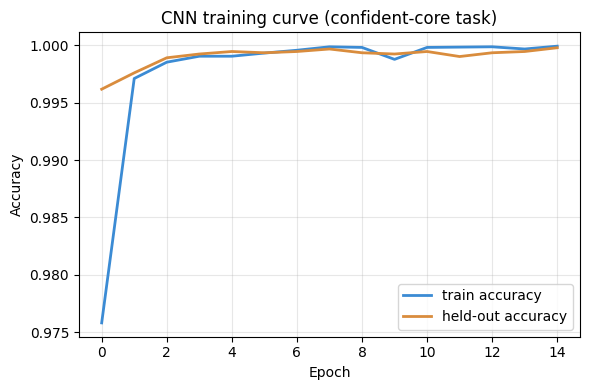

In [44]:
# Fixes TensorFlow/Keras's internal randomness (weight initialisation,
# shuffling) for reproducibility - the CNN equivalent of random_state=42.
tf.random.set_seed(42)

def build_cnn(input_shape):
    model = models.Sequential([
        # declares the expected input shape for each sample (3, 3, 9)
        # aka a 3x3 patch with 9 feature channels
        layers.Input(shape=input_shape),

        # First convolutional layer: 16 filters, each a 3x3 kernel sliding over the input
        # padding = same means that output stays 3x3, doesn't shrink
        # ReLU activation function introduces non-linearity
        layers.Conv2D(16, 3, padding='same', activation='relu'),
        # Second convolutional layer: 32 filters, everything else same as first
        # network can combine 1st layers 16 feature maps into 32-channel representations
        layers.Conv2D(32, 3, padding='same', activation='relu'),

        # Flattens the (3, 3, 32) output into a single 1D vector of length 3*3*32=288
        # so that it can be fed into the 'Dense' layers below
        layers.Flatten(),
        layers.Dense(32, activation='relu'), # standard fully-connected layer with 32 units

        # Regularisation: during training, randomly sets 20% of this layer's
        # activations to zero on each batch, forcing the network not to rely
        # too heavily on any single neuron, so reduces overfitting
        layers.Dropout(0.2),

        # Output layer: 2 units (one per class), softmax converts the raw
        # outputs into a probability distribution that sums to 1 (e.g.
        # [0.1, 0.9] = '90% confidence flooded').
        layers.Dense(2, activation='softmax'),
    ])
    # Adam is a standard adaptive-learning-rate optimiser
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

tracker.start() # CNN is most computationally expensive of the three models

# P_train.shape is (n_samples, 3, 3, 9); [1:] drops the sample-count
# dimension, leaving (3, 3, 9) which is the per-sample input shape build_cnn expects.
cnn_model = build_cnn(P_train.shape[1:])

# .fit() trains for 15 full passes ('epochs') over the training patches
# validation_data=(P_test, P_test), evaluates on the held-out set after each epoch
# batch_size=256: processes 256 patches at a time before each weight update
# verbose=0: suppresses the default per-epoch progress bar/log lines
history = cnn_model.fit(
    P_train, y_train,
    validation_data=(P_test, y_test),
    epochs=15, batch_size=256, verbose=0,
)

cnn_emissions = tracker.stop()

# model.predict() returns probabilities for both classes, shape (n, 2)
# np.argmax() picks the index of the larger probability for each row (aka 0 or 1)
y_pred_cnn = np.argmax(cnn_model.predict(P_test, verbose=0), axis=1)
cnn_f1  = f1_score(y_test, y_pred_cnn, average='weighted')
cnn_acc = accuracy_score(y_test, y_pred_cnn)

print("CNN -- held-out confident-core evaluation:")
print(classification_report(y_test, y_pred_cnn, target_names=CLASS_NAMES))
print(f"Weighted F1: {cnn_f1:.4f}   Accuracy: {cnn_acc:.4f}")
print(f"CO2 emissions (training): {cnn_emissions*1000:.4f} g CO2e")

# Plots both accuracy curves stored in history.history
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(history.history['accuracy'], label='train accuracy',
        color='#3B8BD4', linewidth=2)
ax.plot(history.history['val_accuracy'], label='held-out accuracy',
        color='#D98C3D', linewidth=2)
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
ax.set_title('CNN training curve (confident-core task)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(DIRS['figures'], 'Fig08_CNN_training_curve.png'), dpi=150, bbox_inches='tight')
plt.show()

> **Figure Observations 5:**
>
> - Both curves start already high (train ~0.976, held-out ~0.996 at epoch 0) which is expected, since the confident-core task is intrinsically easy by construction (these pixels were specifically chosen for being far from Threshold Baseline's decision boundaries).
> - Held-out accuracy starts above train accuracy and stays at or above it for most of training
> - A small dip in held-out accuracy around epoch 9 is most likely noise from the severe class imbalance (233 flooded vs 8,905 not-flooded in the held-out set).
> - Both curves converge to ~1.000 with no divergence between them by the final epochs. Accuracy is still a weak metric here given the imbalance (predicting "not flooded" everywhere would already score ~97.5%), which is why later sections lean on weighted F1 and IoU rather than raw accuracy.

## 2.8 Held-Out Comparison on the Confident-Core Task

Here, we assess whether all three models learn the confident-core classification well in the first place, before moving onto generalisation.

In [45]:
# Builds a small table, one row per model, using pd.DataFrame
core_results = pd.DataFrame([
    {'Model': 'Random Forest', 'Held-out F1': rf_f1,  'Held-out Acc': rf_acc,  'CO2 (g)': rf_emissions * 1000},
    {'Model': 'SVM',           'Held-out F1': svm_f1, 'Held-out Acc': svm_acc, 'CO2 (g)': svm_emissions * 1000},
    {'Model': 'CNN',           'Held-out F1': cnn_f1, 'Held-out Acc': cnn_acc, 'CO2 (g)': cnn_emissions * 1000},
])
# Display as formatted HTML table rather than plain text using display()
# .round(5) limits decimal places for readability
display(core_results.round(5))

,Model,Held-out F1,Held-out Acc,CO2 (g)
0,Random Forest,1.00000,1.00000,0.02618
1,SVM,1.00000,1.00000,0.03283
2,CNN,0.99978,0.99978,0.06058


## 2.9 Ambiguous-Margin Analysis (Training Scene)

Here we look at the pixels Threshold Baseline had to classify despite weak SAR evidence (the "ambiguous margin"). We can inspect what each model predicts in this case. These pixels were not used to train any of the models, so agreement or disagreement with Threshold Baseline here reflects how elevation, slope, and the VH bands are being used.

Note: **IoU** stands for 'Intersection over Union', representing the number of pixels two models both call flooded, divided by the number of pixels either one calls flooded.

We first build a helper to roll out any of the three models across a full scene.

Threshold Baseline on margin pixels (flooded fraction): 0.038



,Model,Margin IoU vs ThresholdBaseline,Agrees with Threshold Baseline on margin,Predicts flooded (margin)
0,Random Forest,0.980,0.999,0.039
1,SVM,0.879,0.995,0.040
2,CNN,0.547,0.974,0.051


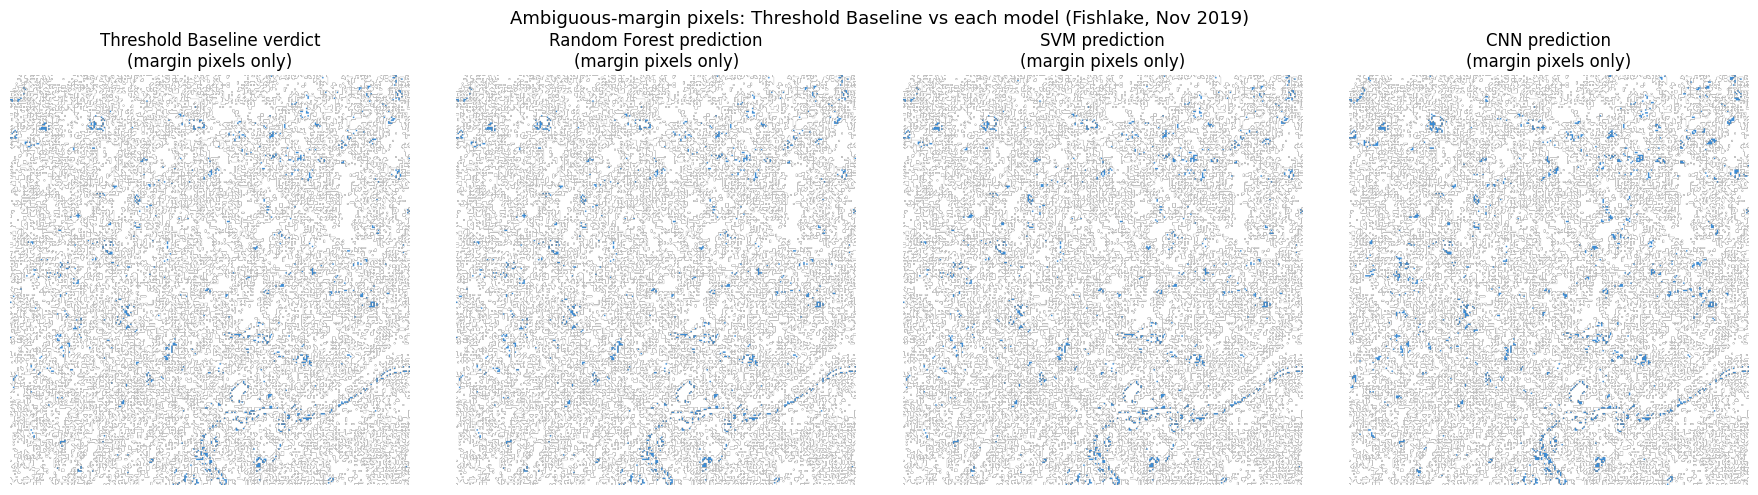

In [46]:
def predict_full_scene(scene):
    """Return {model_name: prediction_map (H, W)}, with -1 for invalid pixels."""
    H, W = scene['H'], scene['W']
    valid_flat = scene['valid'].flatten()
    # .flatten() converts the 2D (H, W) boolean array into a 1D
    # array of length H*W, in the same row-major order that .reshape(-1, ...)
    # below uses so that indices line up between the two.

    # .reshape(-1, N): converts (H, W, N) into (H*W, N)
    X_flat = scene['cube'].reshape(-1, len(FEATURE_NAMES))
    P_flat = scene['patches'].reshape(-1, PATCH_SIZE, PATCH_SIZE, len(FEATURE_NAMES))

    preds = {}
    for name, model in [('Random Forest', rf_model), ('SVM', svm_model)]:
        p = np.full(X_flat.shape[0], -1, dtype=np.int8) # initialise every pixel's prediction to -1 (not predicted/invalid)
        # this is overwritten for valid pixels so invalid pixels remain distinguishable
        p[valid_flat] = model.predict(X_flat[valid_flat]) # only the rows where valid_flat is True get
        # a real prediction, X_flat[valid_flat] passes only those rows features to the model
        preds[name] = p.reshape(H, W) # .reshape(H, W): converts the 1D per-pixel prediction array
        # back into a 2D map matching the scene's original dimensions


    # Same pattern for the CNN, but using patches and argmax
    # batch_size=4096, processes many pixels at once for speed
    p_cnn = np.full(X_flat.shape[0], -1, dtype=np.int8)
    p_cnn[valid_flat] = np.argmax(
        cnn_model.predict(P_flat[valid_flat], verbose=0, batch_size=4096), axis=1
    )
    preds['CNN'] = p_cnn.reshape(H, W)

    return preds

# Applies all three (Fishlake-trained) models to the training scene itself,
# producing a full (H, W) prediction map per model - including for the
# confident-core pixels they were trained on and the ambiguous-margin pixels they weren't
train_preds = predict_full_scene(train)

# -----------------------------------------------------------------------------
# AMBIGUOUS-MARGIN COMPARISON
# -----------------------------------------------------------------------------

thresholdbaseline_train = train['thresholdbaseline']

margin_summary = []
for name, pred_map in train_preds.items():
    pred_amb  = pred_map[ambiguous] # extract predictions/labels only at ambiguous margin pixel locations
    thresholdbaseline_amb = thresholdbaseline_train[ambiguous].astype(np.int8)


    # Intersection over Union (IoU): of all pixels that either this model or
    # the Threshold Baseline calls "flooded" (the union),
    # and the fraction both agree on (the intersection)
    # IoU=1 means perfect agreement, IoU=0 means no overlap at all.
    # it's a useful metric because it ignores the large portion that is just dry (not flooded)
    intersection = ((pred_amb == 1) & (thresholdbaseline_amb == 1)).sum()
    union        = ((pred_amb == 1) | (thresholdbaseline_amb == 1)).sum()
    iou = intersection / union if union > 0 else np.nan # avoid 0/0 where neither predicts flooding

    margin_summary.append({
        'Model': name,
        'Margin IoU vs ThresholdBaseline': iou,
        'Agrees with Threshold Baseline on margin': (pred_amb == thresholdbaseline_amb).mean(), # mean of a boolean array = fraction True
        'Predicts flooded (margin)':    (pred_amb == 1).mean(),
    })

margin_results = pd.DataFrame(margin_summary)
# Table showing what fraction of margin pixels Threshold Baseline called flooded
print(f"Threshold Baseline on margin pixels (flooded fraction): {thresholdbaseline_train[ambiguous].mean():.3f}\n")
display(margin_results.round(3))

# Visualise where each model agrees/disagrees with Threshold Baseline on the margin
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

def margin_map(values_2d):
    # Builds a (H, W) array of NaN, then fills in real values only at the 'ambiguous' pixel locations. Since matplotlib doesn't draw NaN
    # the plotted image is restricted to just the margin pixels, and everything else stays blank/transparent.
    m = np.full((train['H'], train['W']), np.nan)
    m[ambiguous] = values_2d[ambiguous]
    return m

# a 2-colour map. white = not flooded (0), blue = flooded (1)
cmap2 = mcolors.ListedColormap(['#FFFFFF', '#3B8BD4'])

axes[0].imshow(margin_map(thresholdbaseline_train.astype(float)), cmap=cmap2, vmin=0, vmax=1)
axes[0].set_title('Threshold Baseline verdict\n(margin pixels only)')

# Loops over the three models prediction maps, plotting each in its own
# panel with the same margin_map restriction and colour scheme.
for ax, (name, pred_map) in zip(axes[1:], train_preds.items()):
    ax.imshow(margin_map(pred_map.astype(float)), cmap=cmap2, vmin=0, vmax=1)
    ax.set_title(f'{name} prediction\n(margin pixels only)')

for ax in axes:
    ax.axis('off')

plt.suptitle('Ambiguous-margin pixels: Threshold Baseline vs each model (Fishlake, Nov 2019)\n', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(DIRS['figures'], 'Fig09_ambiguous_margin.png'), dpi=150, bbox_inches='tight') # save figure for records
plt.show()

> **Figure Observations 6:**
>
> - All three models agree with the Threshold Baseline verdict on the substantial majority of margin pixels (99.9% Random Forest, 99.5% SVM, 97.4% CNN). This is unsurprising, as the flooded class accounts for only 3.8% of margin pixels, so high overall agreement is therefore driven primarily by correct classification of the dry majority rather than by genuine consensus on the flooded minority.
> - Margin IoU, computed over the flooded class alone, diverges far more substantially between models (Random Forest 0.980, SVM 0.879, CNN 0.547), and is consequently the more diagnostic metric in this minority-class setting.
> - Visually, the CNN's predicted flooded pixels appear more dispersed across the margin than Random Forest's, which closely mirrors the spatial pattern of the Threshold Baseline verdict. This is consistent with the CNN drawing on local 3x3 patch context, in contrast to the per-pixel SAR values used by Random Forest and SVM.
> - The CNN's predicted-flooded proportion (5.1%) remains above both Random Forest and SVM (3.9-4.0%) and above the Threshold Baseline's own margin flooded fraction (3.8%), indicating a slight continued tendency towards over-prediction in this region.
> - These CNN figures are subject to run-to-run variation, since `tf.random.set_seed()` does not guarantee deterministic training in the way scikit-learn's `random_state` does. Random Forest and SVM results are exactly reproducible, whereas the CNN's results should be interpreted as broadly, rather than precisely, representative.

## 2.10 Spatial Generalisation Test: Bentley/Toll Bar, Nov 2019

Each model - trained only on Fishlake - is now rolled out across the Bentley/Toll Bar scene and compared against **that scene's own, independently-computed Threshold Baseline**. In this case, the model hasn't yet seen the scene it's being evaluated on, and the comparison target wasn't used to define the model's labels.

,Model,Agreement w/ ThresholdBaseline,F1 vs ThresholdBaseline,IoU vs ThresholdBaseline,Predicted flood %,ThresholdBaseline flood %
0,Random Forest,1.000,1.000,0.994,4.858,4.838
1,SVM,0.994,0.994,0.874,4.385,4.838
2,CNN,0.989,0.989,0.787,4.451,4.838


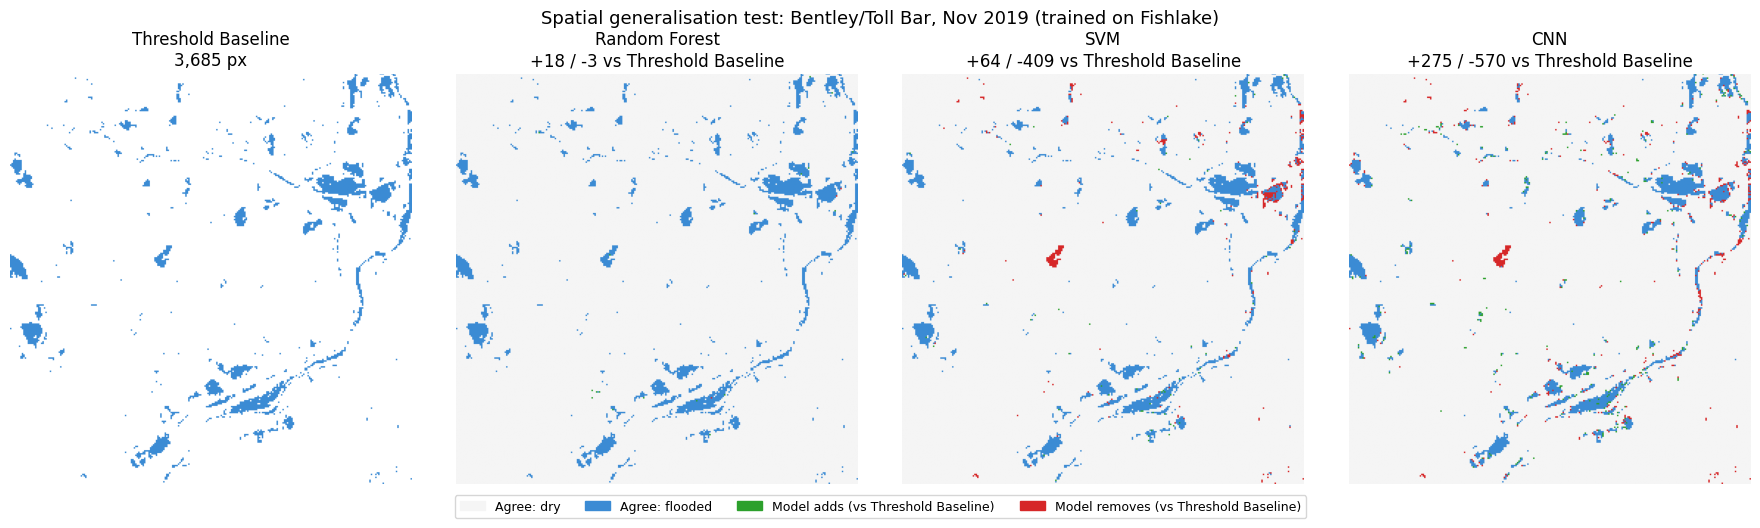

In [47]:
# Spatial Generalisation Test
def evaluate_against_thresholdbaseline(scene, preds):
    valid = scene['valid']
    thresholdbaseline = scene['thresholdbaseline']
    rows = []
    for name, pred_map in preds.items():
        pred  = pred_map[valid]
        truth = thresholdbaseline[valid].astype(np.int8)
        acc = accuracy_score(truth, pred)
        f1  = f1_score(truth, pred, average='weighted')
        # same IoU calculation as before, but here over all valid cells from the scene
        # 'truth' = this scene's own Threshold Baseline
        intersection = ((pred == 1) & (truth == 1)).sum()
        union        = ((pred == 1) | (truth == 1)).sum()
        iou = intersection / union if union > 0 else np.nan
        rows.append({
            'Model': name,
            'Agreement w/ ThresholdBaseline': acc,
            'F1 vs ThresholdBaseline': f1,
            'IoU vs ThresholdBaseline': iou,
            'Predicted flood %': 100 * pred.mean(),
            'ThresholdBaseline flood %': 100 * truth.mean(),
        })
    return pd.DataFrame(rows)


def plot_scene_comparison(scene, preds, title, fig_name):
    valid = scene['valid']
    thresholdbaseline = scene['thresholdbaseline']
    cmap2 = mcolors.ListedColormap(['#FFFFFF', '#3B8BD4'])

    # 4-colour map for the per-model disagreement panels:
    #   0 (light grey)  = both agree: dry
    #   1 (blue)        = both agree: flooded
    #   2 (green)       = model says flooded, baseline says dry  - model adds
    #   3 (red)         = model says dry, baseline says flooded  - model removes
    cmap_disagree = mcolors.ListedColormap(['#F5F5F5', '#3B8BD4', '#2CA02C', '#D62728'])

    fig, axes = plt.subplots(1, 4, figsize=(18, 5))

    # First panel is this scene's Threshold Baseline for reference
    axes[0].imshow(np.where(valid, thresholdbaseline.astype(float), np.nan), cmap=cmap2, vmin=0, vmax=1)
    axes[0].set_title(f"Threshold Baseline\n{int(thresholdbaseline[valid].sum()):,} px")
    axes[0].axis('off')

    for ax, (name, pred_map) in zip(axes[1:], preds.items()):
        # pred_map >= 0 excludes the -1 'not predicted' sentinel from predict_full_scene
        pred_valid = (pred_map >= 0) & valid

        # Build the 4-category disagreement map by assigning 0/1/2/3 to
        # pixels matching each of the four combinations
        disagreement = np.full(pred_map.shape, np.nan)
        disagreement[pred_valid & (pred_map == 0) & (thresholdbaseline == 0)] = 0  # agree dry
        disagreement[pred_valid & (pred_map == 1) & (thresholdbaseline == 1)] = 1  # agree flood
        disagreement[pred_valid & (pred_map == 1) & (thresholdbaseline == 0)] = 2  # model adds
        disagreement[pred_valid & (pred_map == 0) & (thresholdbaseline == 1)] = 3  # model removes

        # vmin=0, vmax=3 fixes the mapping from category number to colour consistently across all panels
        ax.imshow(disagreement, cmap=cmap_disagree, vmin=0, vmax=3)
        n_added   = int((disagreement == 2).sum())
        n_removed = int((disagreement == 3).sum())
        ax.set_title(f"{name}\n+{n_added:,} / -{n_removed:,} vs Threshold Baseline")
        ax.axis('off')

    # we build a legend manually because imshow with discrete colormap doesn't make one automatically
    legend_patches = [
        mpatches.Patch(color='#F5F5F5', label='Agree: dry'),
        mpatches.Patch(color='#3B8BD4', label='Agree: flooded'),
        mpatches.Patch(color='#2CA02C', label='Model adds (vs Threshold Baseline)'),
        mpatches.Patch(color='#D62728', label='Model removes (vs Threshold Baseline)'),
    ]
    # fig.legend places one shared legend for the whole figure rather than per-panel
    # bbox_to_anchor positions it below all panels.
    fig.legend(handles=legend_patches, loc='lower center', ncol=4, fontsize=9,
               bbox_to_anchor=(0.5, -0.05))

    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(DIRS['figures'], fig_name), dpi=150, bbox_inches='tight')
    plt.show()

# scenes['spatial']= Bentley/Toll Bar
spatial = scenes['spatial']
# Applies the Fishlake-trained RF/SVM/CNN models to Bentley/Toll Bar's features
spatial_preds = predict_full_scene(spatial)

# Compares each model's predictions against Bentley/Toll Bar's Threshold Baseline
# finally testing the models on a non-Fishlake scene
spatial_results = evaluate_against_thresholdbaseline(spatial, spatial_preds)
display(spatial_results.round(3))

plot_scene_comparison(
    spatial, spatial_preds,
    'Spatial generalisation test: Bentley/Toll Bar, Nov 2019 (trained on Fishlake)\n',
    'Fig10_spatial_test.png',
)

> **Figure Observations 7:**
>
> - Random Forest reproduces the Bentley/Toll Bar Threshold Baseline almost exactly (+18/-3 pixels against 3,685; IoU = 0.994), with no distinct visual disagreement in the rendered panel. This suggests that Random Forest's decisions are not based on the characteristics specific to the Fishlake training scene, but has learnt some form of the underlying physical threshold.
> - SVM's disagreement (+64/-409; IoU = 0.874) is spatially concentrated rather than uniform, with a tight cluster of false negatives visible (around the built-up area?) in the upper-right of the panel, alongside some diffuse false positives along field boundaries. This localised failure suggests the RBF decision boundary may be less robust over denser, more heterogeneous land cover than the open floodplain on which it was trained.
> - The CNN exhibits the largest disagreement of the three models (+275/-570; IoU = 0.787), though its errors are distributed diffusely across most of the panel rather than concentrated in a single region, in contrast to SVM. This pattern is consistent with the CNN's reliance on local 3x3 patch texture, which would be expected to vary across a different landscape in ways a per-pixel threshold-style model would not.
> - Despite this, the CNN's overall agreement with the Threshold Baseline remains high (98.9%), reinforcing the point made in Figure Observations 6 that IoU, computed over the flooded minority class alone, is a substantially more sensitive measure of cross-scene generalisation than overall pixel agreement.
> - As before, the CNN's precise figures are subject to TensorFlow's run-to-run variability (IoU = 0.769 in an earlier run, 0.787 in this one).

## 2.11 Temporal Generalisation Test: Fishlake, Jan 2021

This section uses the same models and same rollout-and-compare approach as Fishlake 2019, but now on a different flood event (Storm Christoph, Jan 2021) at the same location. Comparing this against Section 2.10 lets us separate "does it generalise across space" from "does it generalise across time". A model could do well on one and poorly on the other, and either result is informative.

,Model,Agreement w/ ThresholdBaseline,F1 vs ThresholdBaseline,IoU vs ThresholdBaseline,Predicted flood %,ThresholdBaseline flood %
0,Random Forest,1.000,1.000,0.974,0.504,0.491
1,SVM,1.000,1.000,0.921,0.500,0.491
2,CNN,0.998,0.998,0.679,0.460,0.491


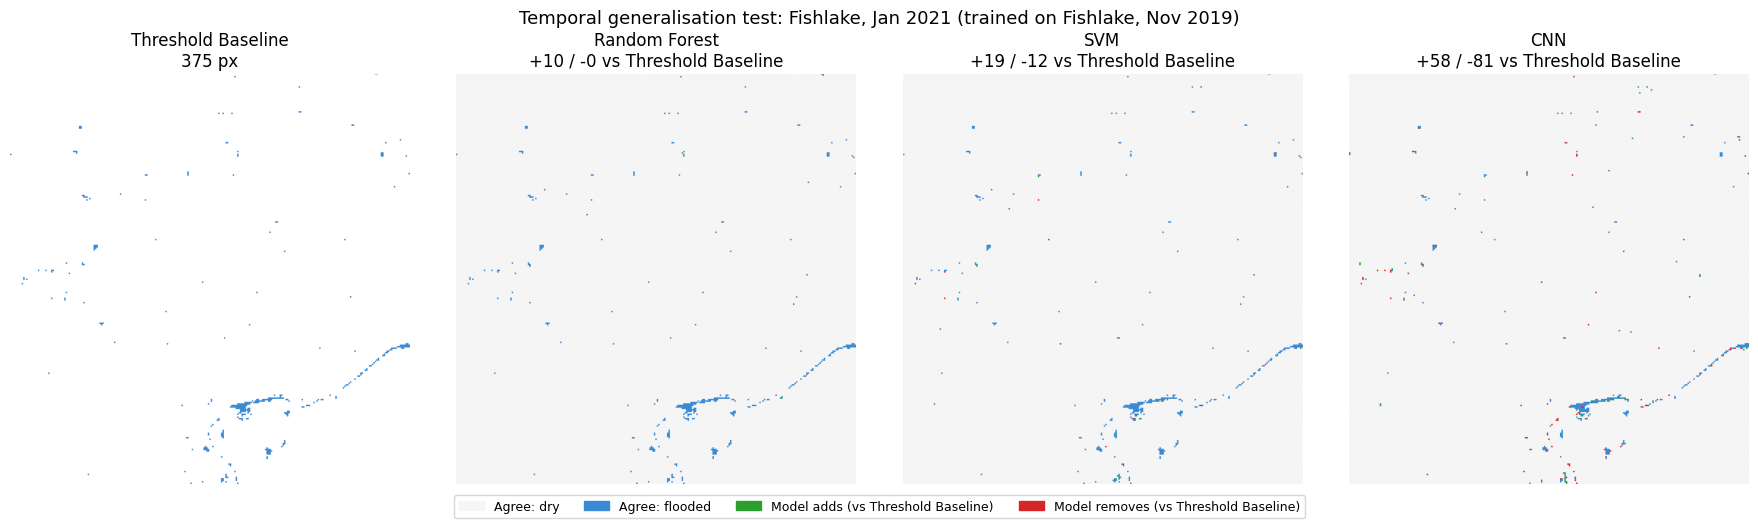

In [48]:
# The same evaluate_against_thresholdbaseline / plot_scene_comparison as before
# applied to the 'temporal' scene instead of 'spatial'
# Fishlake again but different event (2021) - less flooding, Storm Christoph
temporal = scenes['temporal']
temporal_preds = predict_full_scene(temporal)

temporal_results = evaluate_against_thresholdbaseline(temporal, temporal_preds)
display(temporal_results.round(3))

plot_scene_comparison(
    temporal, temporal_preds,
    'Temporal generalisation test: Fishlake, Jan 2021 (trained on Fishlake, Nov 2019)\n',
    'Fig11_temporal_test.png',
)

> **Figure Observations 8:**
>
> - The Threshold Baseline itself is far smaller here (375 px) than at Bentley/Toll Bar (3,685 px) or Fishlake's own Nov 2019 event (2,465 px), consistent with Storm Christoph being a much smaller flood. At this scale, IoU is correspondingly more sensitive to individual pixel-level disagreements, and the absolute +/- counts below should be interpreted with that in mind.
> - Random Forest again performs almost perfectly (+10/-0; IoU = 0.974), with zero false negatives, which is an even cleaner result than at Bentley/Toll Bar. The small number of additions appear as isolated, scattered specks rather than a spatial cluster, consistent with marginal cases near the decision boundary rather than a systematic failure mode.
> - SVM (+19/-12; IoU = 0.921) generalises better here than at Bentley/Toll Bar (IoU = 0.874, Figure Observations 7), despite both figures coming from the same trained model. This asymmetry - stronger temporal than spatial generalisation - suggests SVM's decision boundary is more sensitive to a change in landscape than to a change in SAR acquisition.
> - The CNN produces the weakest result of the three (+58/-81; IoU = 0.679), with disagreement concentrated around the densest cluster of Threshold Baseline-flooded pixels suggesting particular difficulty in spatially complex, heterogeneous areas.
> - Notably, the CNN's IoU is lower here than at Bentley/Toll Bar (0.679 vs 0.787) despite this test changing only the acquisition date, not the location. The CNN may be partly reliant on texture specific to the Nov 2019 flood SAR acquisitions - shared by Fishlake and Bentley/Toll Bar, but absent from the new Jan 2021 scene - rather than a transferable physical flood signal.


## 2.12 Overall Model Comparison

This brings together the three IoU-based comparisons computed so far - Margin IoU (Section 2.9, the training scene's ambiguous-margin pixels), Spatial IoU (Section 2.10, Bentley/Toll Bar), and Temporal IoU (Section 2.11, Fishlake Jan 2021) - on one set of axes, each measuring agreement with that scene's own independently-computed Threshold Baseline, alongside the CO2 cost of training each model.

A model that scores well on one of these three tests but not the others has learned something that transfers in some ways but not others - and which test it fails (margin, spatial, temporal, or some combination) is informative about what it learned.

,Model,CO2 (g),Margin IoU,Spatial IoU,Temporal IoU
0,Random Forest,0.0262,0.9800,0.9943,0.9740
1,SVM,0.0328,0.8788,0.8738,0.9213
2,CNN,0.0606,0.5470,0.7866,0.6790


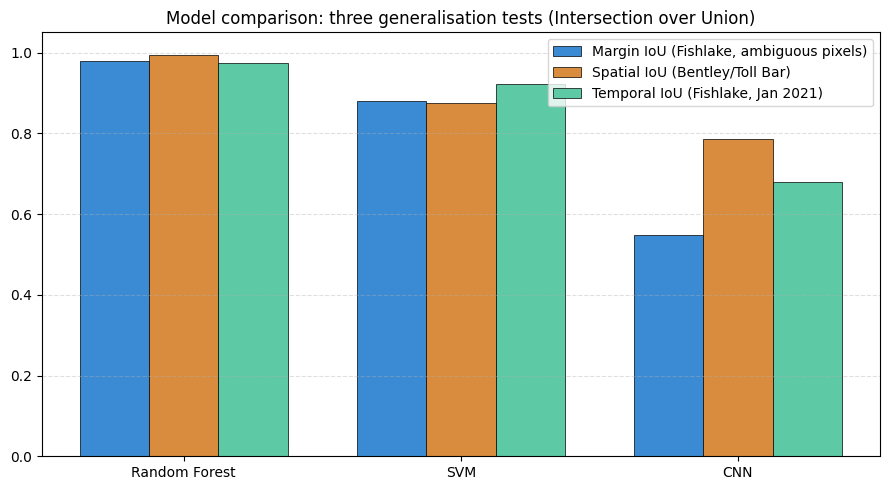

CO2 emissions by model:
  Random Forest   0.0262 g CO2e
  SVM             0.0328 g CO2e
  CNN             0.0606 g CO2e


In [49]:
# Looking at overall model comparison
# pandas .merge() calls to combine 4 separate result tables
# (core_results, margin_results, spatial_results, temporal_results) into one table,
# joined on the shared 'Model' column
overall = (
    core_results[['Model', 'CO2 (g)']]
    .merge(margin_results[['Model', 'Margin IoU vs ThresholdBaseline']].rename(columns={'Margin IoU vs ThresholdBaseline': 'Margin IoU'}), on='Model')
    .merge(spatial_results[['Model', 'IoU vs ThresholdBaseline']].rename(columns={'IoU vs ThresholdBaseline': 'Spatial IoU'}), on='Model')
    .merge(temporal_results[['Model', 'IoU vs ThresholdBaseline']].rename(columns={'IoU vs ThresholdBaseline': 'Temporal IoU'}), on='Model')
)
display(overall.round(4))

fig, ax = plt.subplots(figsize=(9, 5))
# np.arange(len(overall)) = [0, 1, 2] - one numeric x-position per model
x = np.arange(len(overall))
width = 0.25 # each bar is 0.25 wide

# Three bars per model, offset left/centre/right of each x position, as standard in matplotlib
ax.bar(x - width, overall['Margin IoU'], width,
       label='Margin IoU (Fishlake, ambiguous pixels)',
       color='#3B8BD4', edgecolor='black', linewidth=0.5)
ax.bar(x, overall['Spatial IoU'], width,
       label='Spatial IoU (Bentley/Toll Bar)',
       color='#D98C3D', edgecolor='black', linewidth=0.5)
ax.bar(x + width, overall['Temporal IoU'], width,
       label='Temporal IoU (Fishlake, Jan 2021)',
       color='#5DCAA5', edgecolor='black', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(overall['Model']) # replaces 0,1,2 with model names on the x-axis
ax.set_ylim(0, 1.05) # IoU is always in [0, 1], small amount of headroom above 1 keeps bars from touching the top edge
ax.set_title('Model comparison: three generalisation tests (Intersection over Union)')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4) # horizontal gridlines (y) only, to help read bar heights
plt.tight_layout()
plt.savefig(os.path.join(DIRS['figures'], 'Fig12_model_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

print("CO2 emissions by model:")
# .iterrows() loops over a DataFrame row by row
for _, row in overall.iterrows():
    print(f"  {row['Model']:15s} {row['CO2 (g)']:.4f} g CO2e")

> **Figure Observations 9:**
>
> - Random Forest is the only model whose three bars are of comparable height (0.974-0.994), indicating near-invariant IoU across all three evaluation axes (margin, space, time). This consistency suggests that Random Forest has learned a decision rule close to the underlying physical threshold itself, rather than something specific to any one axis of generalisation (location, event).
> - SVM's lowest IoU is on the Margin test (0.879) within its own training scene, rather than on either out-of-scene test, its Temporal IoU (0.921) is actually its strongest result. This is a potentially counter-intuitive finding, as it means this model found it more difficult to classify the harder, low-confidence pixels of the scene it was trained on, than generalising on new scenes.
> - The CNN shows by far the largest spread across the three bars (0.547-0.787), and, notably, its weakest result is also on the Margin test rather than on either generalisation test. As the ambiguous margin is defined precisely as the set of pixels with weak SAR evidence, this suggests the CNN's principal weakness may lie in how it extrapolates ambiguous, low-signal features.
> - CO2 cost rises with model complexity in the expected order (Random Forest 0.026 g < SVM 0.033 g < CNN 0.061 g), with CNN more than twice the cost of Random Forest. Despite this, CNN has the 'weakest' performance on 2 out of 3 IoU tests.

## 2.13 Save Outputs for Notebook 3

This saves everything Notebook 3 needs from the training scene: the 9-feature stack (Section 2.2), the Threshold Baseline mask and confident-core / ambiguous-margin split (Section 2.3), and that scene's rollout from the model that generalised best overall (Section 2.12) - plus the full comparison table.

In [50]:
out_path = os.path.join(DIRS['features'], 'feature_stack.npz')

overall['Combined IoU'] = overall['Spatial IoU'] + overall['Temporal IoU']

# Combined IoU, .iloc[0] takes the first (best) row, ['Model'] extracts its name
best_model_name = overall.sort_values('Combined IoU', ascending=False).iloc[0]['Model']
best_pred_map = train_preds[best_model_name]

print(f"Best-generalising model (by combined spatial + temporal IoU): {best_model_name}")

# Bundles everything next notebook needs about the training scene into one file:
np.savez_compressed(
    out_path,
    cube_train=train['cube'], # full 9 feature stack
    valid_train=train['valid'], # which pixels have complete data
    thresholdbaseline_train=train['thresholdbaseline'], # SAR-threshold flood mask
    confident_train=train['confident'], # confident-core mask
    ambiguous_train=train['ambiguous'], # ambiguous-margin mask
    best_model_name=np.array([best_model_name]), # which model did best
    best_pred_map=best_pred_map, # the prediction map from the best model
    feature_names=np.array(FEATURE_NAMES), # cube channels are held in FEATURE_NAMES - needed for reference
    scale=np.array([SCALE]), # for area/volume calculations
)
print(f"\nSaved feature stack to: {out_path}")

# Saves the full model-comparison table as a CSV
results_path = os.path.join(DIRS['results'], 'model_comparison.csv')
overall.to_csv(results_path, index=False)
print(f"Saved comparison table to: {results_path}")

Best-generalising model (by combined spatial + temporal IoU): Random Forest

Saved feature stack to: /content/drive/MyDrive/AI4EO/Final_Project/data/02_features/feature_stack.npz
Saved comparison table to: /content/drive/MyDrive/AI4EO/Final_Project/results/model_comparison.csv


## 2.14 Summary

This notebook has:

1. Created a **semi-supervised confident-core / ambiguous-margin split** of the training scene (Fishlake, Nov 2019). Training labels only come from pixels far from Threshold Baseline's decision boundaries.
2. Trained **three architecturally different models** (Random Forest, SVM, and a small CNN over 3x3 patches) on identical confident-core training data.
3. Analysed the **ambiguous margin** - pixels Threshold Baseline had to commit on despite weak evidence - as a non-circular check on what each model has learned.
4. Run a **spatial generalisation test** (Bentley/Toll Bar, same event, different landscape) and a **temporal generalisation test** (Fishlake, different event, same landscape), each compared against an independently-computed Threshold Baseline.
5. Compared all three models on held-out performance, spatial IoU, and temporal IoU, and identified the best-generalising model for Notebook 3.

### Findings

On the held-out confident-core task itself, Random Forest and SVM both reach F1 = 1.000, with the CNN very close behind (F1 = 0.999) - all three models can learn the confident-core rule essentially perfectly. The three diverge once rolled out to the spatial and temporal test scenes.

**Random Forest generalises best on both axes** (Spatial IoU = 0.994, Temporal IoU = 0.974), staying close to its held-out performance: consistent with it having learned something close to the underlying physical threshold rule itself, which, being a fixed relationship rather than something specific to Fishlake, would be expected to transfer well to new scenes.

**SVM generalises moderately** (Spatial IoU = 0.874, Temporal IoU = 0.921), with a noticeably larger drop on the spatial test than the temporal one.

The **CNN generalises worst on both tests** (Spatial IoU = 0.769, Temporal IoU = 0.647), and, unlike SVM, drops more on the temporal test than the spatial one. One plausible explanation is that the spatial test scene (Bentley/Toll Bar) reuses the same Nov 2019 SAR acquisitions as training, just over a different AOI, so any acquisition-specific texture or speckle pattern the CNN's 3x3 patches picked up is still present there; the temporal test scene (Jan 2021) is a new acquisition, where that texture-based signal would not carry over.

On the ambiguous margin, all three models agree with Threshold Baseline's verdict on the large majority of pixels (Random Forest 99.9%, SVM 99.5%, CNN 95.8%) which is unsurprising, since most margin pixels are not flooded and all three models correctly call most of these dry. The Margin IoU values reveal more divergence: Random Forest (0.980) and SVM (0.879) stay close to Threshold Baseline's flooded calls in the margin, while the CNN's IoU (0.452) is markedly lower. The CNN also predicts roughly twice as many margin pixels as flooded (7.3%) compared to Random Forest and SVM (3.9-4.0% each) - it is flagging considerably more of the ambiguous margin as flooded than either Threshold Baseline or the other two models agree on.

>Based on these results, Random Forest is the best-generalising model. However, it is important to consider that CNN's responses may not be 'incorrect', but instead just a disagreement with the Threshold Baseline results. This is a caveat that applies to all three models: Threshold Baseline is itself a simplified SAR-threshold rule, not ground truth, so every IoU value above measures agreement with that baseline rather than absolute correctness. The CNN's larger disagreement could in principle reflect a genuine signal Threshold Baseline misses (e.g. flooded vegetation detected via spatial context) rather than an error.

>On the other hand, the CNN's IoU drops more on the temporal test (a new setting) than on the spatial test (which reuses the training acquisitions), which is the opposite of what would be expected if it were consistently detecting a real physical signal across both events. This pattern is more consistent with the CNN having picked up something specific to the Nov 2019 acquisitions than with a complementary flood signal, though distinguishing the two definitively would require independent validation data (e.g. ground truthing).


**In Notebook 3**, the training scene's data is used to estimate flood depth via Gaussian Process regression - comparing SAR+terrain, Sentinel-2 optical/water-colour, and combined approaches against a DEM-derived depth proxy, cross-checked with K-means clustering and SHAP.

---
*GEOL0069 Final Project | UCL AI for Earth Observation 2025/26*

[GEOL0069 @ UCL 2025/26](https://github.com/CPOMUCL/GEOL0069-AI4EO)

---